This project is to analyze water shed prediction. the data is based of total nitrogen, total phosphorus, and chloraphyll a. We will focus on Nitrogen levels.

In [1]:
import pandas as pd 

In [2]:
raw_data = pd.read_csv("WatershedPredictions.csv")

In [3]:
raw_data

,wbCOMID,TN_0705,TP_0705,Chla_0705,TN_0707,TP_0707,Chla_0707,TN_0710,TP_0710,Chla_0710,TN_1205,TP_1205,Chla_1205,TN_1207,TP_1207,Chla_1207,TN_1210,TP_1210,Chla_1210
0,487,398.762417,15.309482,4.842808,430.774885,15.121673,4.863296,414.628041,18.452892,5.285723,410.694781,15.347816,4.736618,409.926574,15.782892,4.634059,465.337736,20.890706,6.161583
1,489,468.631484,17.292297,5.659045,518.147465,17.053761,5.547219,471.956176,19.600563,5.912292,464.197601,17.607895,5.734447,466.571154,17.908353,5.339554,517.621193,22.397095,6.554030
2,491,270.884190,5.534936,3.267304,268.549410,5.424093,3.092850,266.564128,5.766988,3.184790,270.374270,7.408408,2.950850,267.097592,7.874892,2.933530,282.732453,7.688158,3.124080
3,493,510.682727,17.927439,6.149171,530.603068,17.328324,5.853569,516.390018,21.964953,6.634120,506.967562,18.001563,5.928775,480.574953,17.576357,5.323662,494.261693,24.025624,6.253502
4,495,425.642142,14.942664,5.230000,431.813643,14.404113,4.916214,471.773284,17.601767,5.814045,398.128380,15.181981,4.544981,396.632149,15.451457,4.340317,452.289276,20.198440,5.567148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112016,940290002,1242.373899,50.429527,25.830630,1133.688372,48.908025,25.432429,1166.657236,41.140456,22.058147,1026.148937,45.963121,23.588404,987.160158,54.466267,22.868337,1122.725980,45.177897,22.763898
112017,941070128,751.773611,26.540582,11.713041,702.196233,26.008448,10.868209,696.696688,23.404803,9.514620,767.696128,27.065272,12.085771,720.777205,24.131493,10.208676,762.518763,25.546741,11.506723
112018,945040338,1270.558599,144.285255,15.890973,1189.485989,138.728497,14.136169,1354.051245,137.262961,18.231374,1251.161849,116.631150,14.437547,1301.417621,120.759956,14.952874,1375.819330,118.415959,18.078757
112019,945040353,1257.757418,135.580837,15.379946,1206.546442,131.677865,14.681723,1313.447693,131.725245,17.825406,1253.198294,112.676530,14.934690,1269.397012,113.286781,14.770109,1410.439933,117.988150,18.444606


Choosing to focus on Nitrogen levels 

In [4]:
tn_cols = [col for col in raw_data.columns if "TN" in col]
df_tn = raw_data[["wbCOMID"] + tn_cols]
df_tn.head()

,wbCOMID,TN_0705,TN_0707,TN_0710,TN_1205,TN_1207,TN_1210
0,487,398.762417,430.774885,414.628041,410.694781,409.926574,465.337736
1,489,468.631484,518.147465,471.956176,464.197601,466.571154,517.621193
2,491,270.884190,268.549410,266.564128,270.374270,267.097592,282.732453
3,493,510.682727,530.603068,516.390018,506.967562,480.574953,494.261693
4,495,425.642142,431.813643,471.773284,398.128380,396.632149,452.289276


The total nitrogen levels data seems to be from months May, July, and October for years 2007 and 2012

In [5]:
df_long = df_tn.melt(
    id_vars="wbCOMID",
    var_name="measurement",
    value_name="nitrogen_value")

In [6]:
df_long[["parameter","date"]] = df_long["measurement"].str.split("_", expand=True)

In [7]:
df_long = df_long.drop(columns=["measurement","parameter"])
df_long

,wbCOMID,nitrogen_value,date
0,487,398.762417,0705
1,489,468.631484,0705
2,491,270.884190,0705
3,493,510.682727,0705
4,495,425.642142,0705
...,...,...,...
672121,940290002,1122.725980,1210
672122,941070128,762.518763,1210
672123,945040338,1375.819330,1210
672124,945040353,1410.439933,1210


Fixing the Date to be more readable, seperationg months and years and reformating it

In [17]:
df_long["date"] = df_long["date"].astype(str)

In [ ]:
df_long["year"] = df_long["date"].str[:2]
df_long["month"] = df_long["date"].str[2:]

In [29]:
df_long["Date"] = df_long["month"] + "-" + df_long["year"]

In [34]:
df_long = df_long.drop(columns = ["date","month","year"])

In [43]:
df_long

,wbCOMID,nitrogen_value,Date
0,487,398.762417,05-2007
1,489,468.631484,05-2007
2,491,270.884190,05-2007
3,493,510.682727,05-2007
4,495,425.642142,05-2007
...,...,...,...
672121,940290002,1122.725980,10-2012
672122,941070128,762.518763,10-2012
672123,945040338,1375.819330,10-2012
672124,945040353,1410.439933,10-2012


Too many vlaues to visualize, there are multiple values for each date so average is going to be used.

In [44]:
Ntrend = df_long.groupby("Date")["nitrogen_value"].mean().reset_index()

In [45]:
Ntrend

,Date,nitrogen_value
0,05-2007,1064.717288
1,05-2012,999.692647
2,07-2007,1059.757474
3,07-2012,1021.061547
4,10-2007,1061.062305
5,10-2012,1016.253643


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

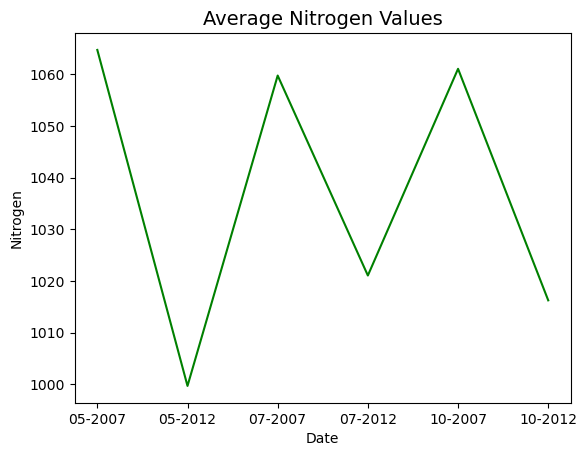

In [52]:
plt.plot(Ntrend['Date'], 
         Ntrend['nitrogen_value'],
         color = 'green')
plt.title("Average Nitrogen Values", fontsize = 14)
plt.ylabel("Nitrogen")
plt.xlabel("Date")
plt.show()

In [55]:
pd.to_datetime(Ntrend["Date"])

0   2007-05-01
1   2012-05-01
2   2007-07-01
3   2012-07-01
4   2007-10-01
5   2012-10-01
Name: Date, dtype: datetime64[ns]

In [56]:
Ntrend["Year"] = Ntrend["Date"].dt.year

In [57]:
year_avg = Ntrend.groupby("Year").agg(avg_nitrogen=("nitrogen_value","mean")).reset_index()

year_avg

,Year,avg_nitrogen
0,2007,1061.845689
1,2012,1012.335946


the Nitrogen values are close together and hard to show any real difference no matter what graph

In [61]:
top_sites = df_long.groupby("wbCOMID").agg(
    avg_nitrogen=("nitrogen_value", "mean")
).reset_index()

In [64]:
top_sites = top_sites.sort_values("avg_nitrogen", ascending=False)

sites = top_sites.head(10)
sites

,wbCOMID,avg_nitrogen
87403,17461610,5316.634912
87114,17332061,5303.282830
87113,17331881,5171.787909
87203,17393038,5007.078814
87115,17332075,4998.883713
87195,17390903,4994.672927
87196,17390905,4803.287013
111801,167245631,4792.733521
83925,16031232,4693.424965
83922,16031172,4659.696979


Because the margins are small, other visualizations graphs/charts aren't the best way to view the data. I made two tables one with the yearly average and one with the highest N concentration by waterbody wbCOMID

Nitrogen is an important nutrient to keep eyes on as they can contribute to harful algal blooms. The data we analyzed had pretty stable levels which is why bar and line charts overall weren't good ways to see any difference since the values were very close.